# Slow Dynamics and High Variability in Networks with Clustered Connections




In [1]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

from model import ClusterParams, ModelParams, NeuronNetwork, firing_rate

# Initialize default model parameters

# Setup the base model

# Run and plot an un-clustered network

In [2]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

In [3]:
def plot_spike_raster(spike_monitor_e, spike_monitor_i=None, n_e=0, title="Spike raster"):
    fig, axes = plt.subplots(figsize=(10, 7), sharex=True)

    axes.plot(spike_monitor_e.t / ms, spike_monitor_e.i, ".", markersize=2, label="E")
    if spike_monitor_i is not None:
        axes.plot(
            spike_monitor_i.t / ms,
            spike_monitor_i.i + n_e,
            ".",
            markersize=2,
            label="I",
        )
    axes.set_ylabel("Neuron index")
    axes.set_title(title)
    axes.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

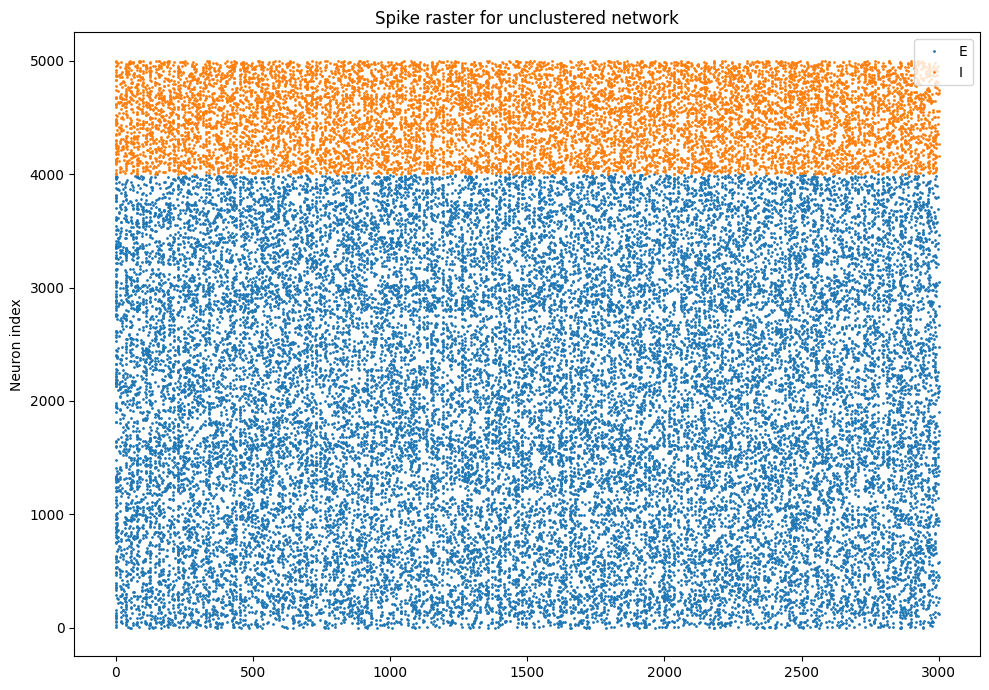

In [4]:
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    unclustered_network.spike_monitor_i,
    n_e=params.N_E,
    title="Spike raster for unclustered network",
)

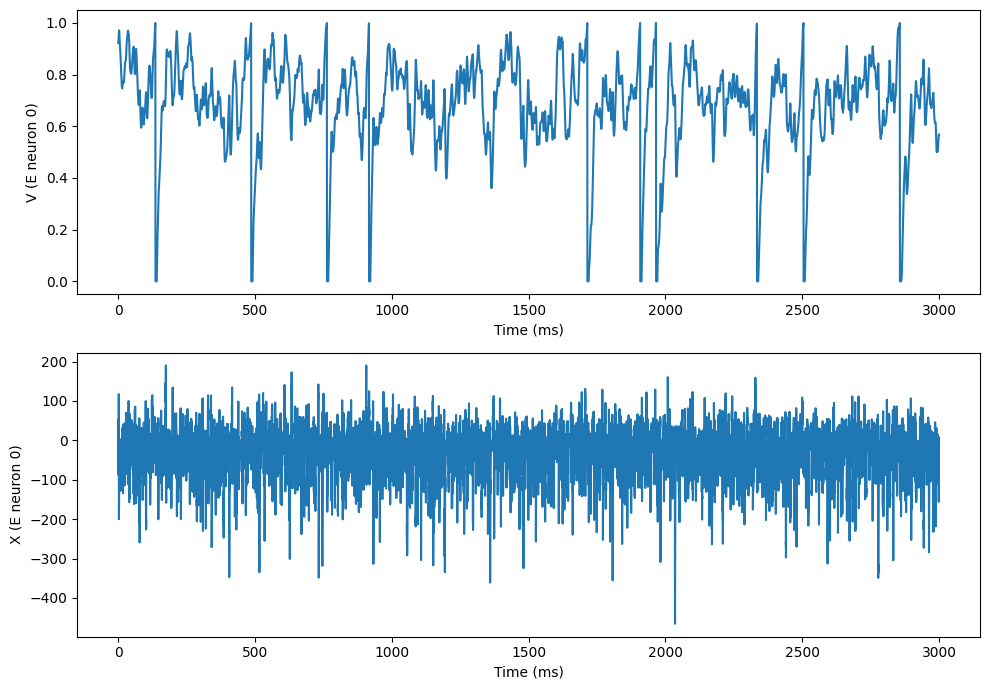

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [6]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

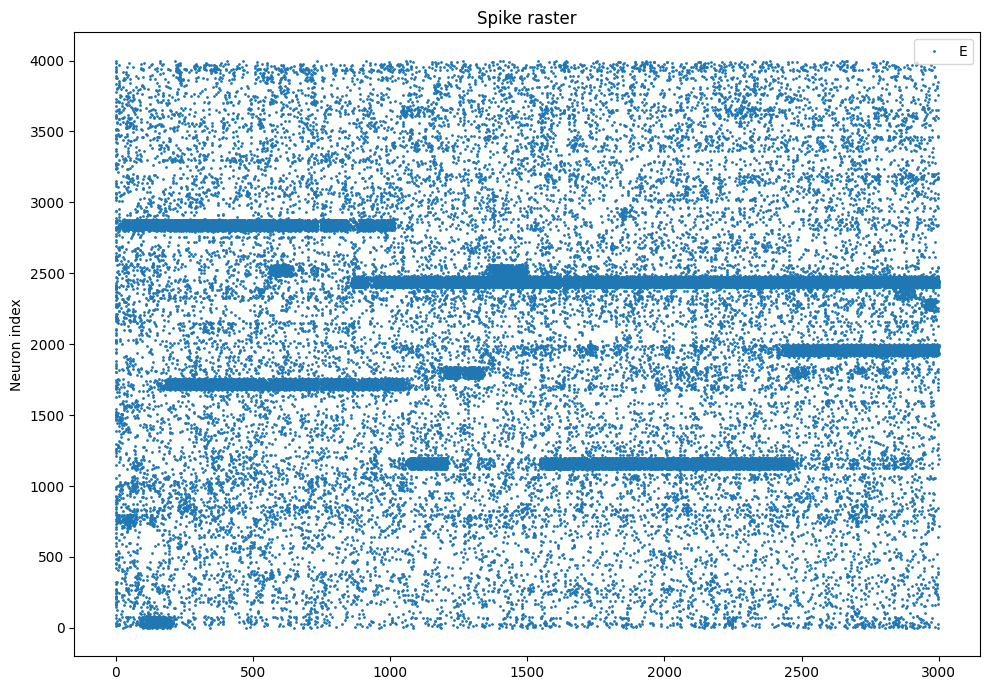

In [7]:
plot_spike_raster(clustered_network.spike_monitor_e)

## Plot the membrane potentials of a few neurons

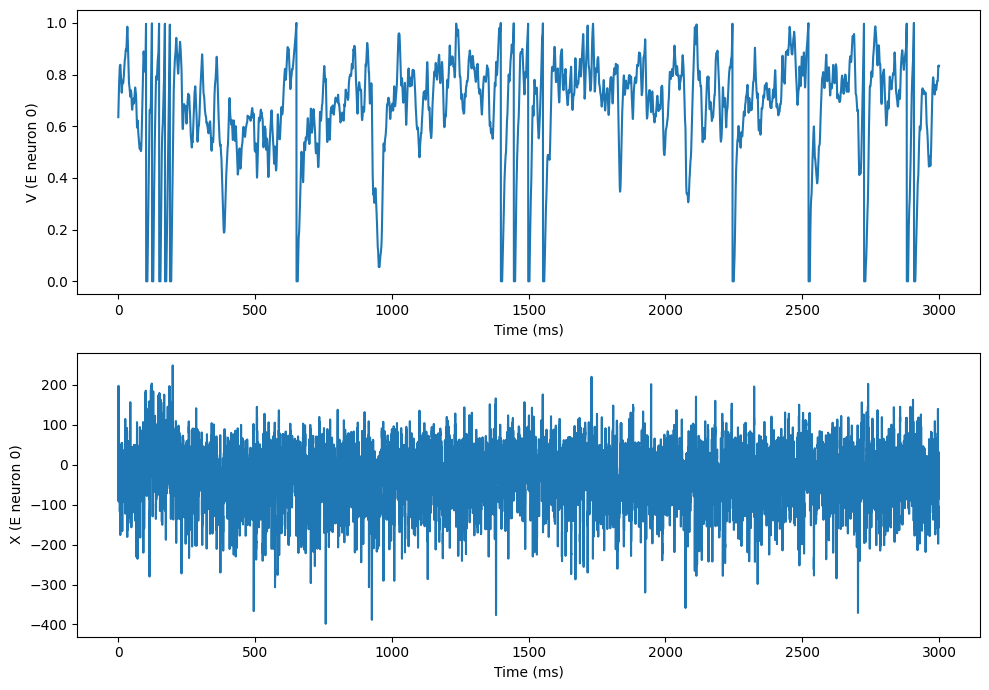

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)
(4000,) (1000,)
(5000,)


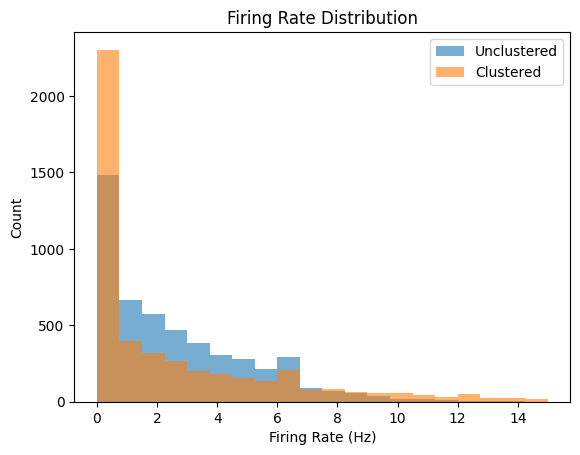

In [9]:
def plot_firing_rate_distribution(networks, labels, title, params):
    fig, ax = plt.subplots()

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=20,
            range=(0, 15),
            alpha=0.6,
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

# Checking difference of exponential filter to an ODE

In [ ]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clutered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

In [ ]:
def window_spikes_all_neurons(spike_times, spike_ids, n_neurons, window, overlap, timerange):
    """Compute spike counts in sliding windows for all neurons at once (vectorized)."""
    start_time = float(timerange[0])
    end_time = float(timerange[1])
    window = float(window)
    overlap = float(overlap)
    
    window_starts = np.arange(start_time, end_time - window + overlap, overlap)
    n_windows = len(window_starts)
    
    window_counts = np.zeros((n_neurons, n_windows), dtype=np.int32)
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids)
    
    for w, ws in enumerate(window_starts):
        mask = (spike_times >= ws) & (spike_times <= ws + window)
        window_counts[:, w] = np.bincount(spike_ids[mask], minlength=n_neurons)
    
    return window_counts


def calc_coeffs(cov_matrix, neuron_vars, params):
    """Calculates the correlation coefficients for all neuron pairs."""
    coeffs = []
    for i in range(params.N_E):
        for j in range(i+1, params.N_E):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)


def calc_cluster_coeffs(cov_matrix, neuron_vars, params, cluster_params):
    """Calculates correlation coefficients for same-cluster pairs only."""
    coeffs = []
    n_cluster = cluster_params.cluster_size
    for i in range(params.N_E):
        j_same_cluster = (i // n_cluster)*n_cluster + n_cluster
        for j in range(i+1, j_same_cluster):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)


class Experiment:
    def __init__(
        self,
        realizations=12,
        trials=9,
        model_params=ModelParams(),
        cluster_params=ClusterParams(enabled=True, R_ee=2.5),
        seed=42,
        corr_window=50*ms,
        corr_overlap=2*ms,
    ):
        self.realizations = realizations
        self.trials = trials
        self.model_params = model_params
        self.cluster_params = cluster_params
        self.seed = seed
        
        # Correlation analysis parameters
        self.corr_window = corr_window
        self.corr_overlap = corr_overlap
        
        # Initialize networks
        self.uniform_networks = self._initialize_networks(
            realizations, model_params, ClusterParams(enabled=True, R_ee=1.0), "uniform"
        )
        self.clustered_networks = self._initialize_networks(
            realizations, model_params, cluster_params, "clustered"
        )
        
        # Fano factor spike counts: (realizations, trials, N_E)
        counts_shape = (realizations, trials, model_params.N_E)
        self.uniform_spike_counts = np.zeros(counts_shape, dtype=np.int32)
        self.clustered_spike_counts = np.zeros(counts_shape, dtype=np.int32)
        
        # Correlation accumulators: accumulate covariance/variance across all trials
        # We compute running sums and divide at the end to get means
        n_e = model_params.N_E
        self.uniform_cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        self.uniform_var_sum = np.zeros(n_e, dtype=np.float64)
        self.clustered_cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        self.clustered_var_sum = np.zeros(n_e, dtype=np.float64)

    def _initialize_networks(self, realizations, model_params, cluster_params, name):
        networks = []
        for r in range(realizations):
            network = NeuronNetwork(model_params, cluster_params, seed=self.seed + 1000 * r)
            print(f"Built {name} network {r + 1}/{realizations}")
            networks.append(network)
        return networks

    def run(self):
        print("Running uniform networks...")
        self._run_networks(
            self.uniform_networks, 
            self.uniform_spike_counts,
            self.uniform_cov_sum,
            self.uniform_var_sum
        )
        print("Running clustered networks...")
        self._run_networks(
            self.clustered_networks, 
            self.clustered_spike_counts,
            self.clustered_cov_sum,
            self.clustered_var_sum
        )
        print("Done.")

    def _run_networks(self, networks, spike_counts, cov_sum, var_sum):
        params = self.model_params
        start_t = params.analysis_start_t
        end_t = start_t + params.analysis_window_t
        fano_end_t = start_t + params.fano_factor_window_t
        timerange = (start_t, end_t)

        for r, network in enumerate(networks):
            for t in range(self.trials):
                network.run()
                
                spike_times = network.spike_monitor_e.t
                spike_ids = network.spike_monitor_e.i
                
                # Fano factor: count spikes in the fano_factor_window
                fano_mask = (spike_times >= start_t) & (spike_times < fano_end_t)
                spike_counts[r, t, :] = np.bincount(
                    spike_ids[fano_mask], minlength=params.N_E
                )
                
                # Correlation: compute window counts and accumulate cov/var
                window_counts = window_spikes_all_neurons(
                    spike_times, spike_ids, params.N_E,
                    self.corr_window, self.corr_overlap, timerange
                )
                cov_matrix = np.cov(window_counts, rowvar=True, bias=False)
                row_vars = np.var(window_counts, axis=1, ddof=1)
                
                cov_sum += cov_matrix
                var_sum += row_vars
                
                print(f"  Realization {r + 1}/{len(networks)}, Trial {t + 1}/{self.trials}")

    def _compute_fano_factor(self, spike_counts):
        mean = spike_counts.mean(axis=1)
        var = spike_counts.var(axis=1, ddof=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(mean > 0, var / mean, np.nan)

    def fano_factor(self):
        return (
            self._compute_fano_factor(self.uniform_spike_counts),
            self._compute_fano_factor(self.clustered_spike_counts),
        )

    def mean_cov_var(self):
        """Get mean covariance matrices and variances from accumulated sums."""
        total_trials = self.realizations * self.trials
        return (
            self.uniform_cov_sum / total_trials,
            self.uniform_var_sum / total_trials,
            self.clustered_cov_sum / total_trials,
            self.clustered_var_sum / total_trials,
        )

    def correlation_coefficients(self, same_cluster_only=False):
        """Compute correlation coefficients from accumulated statistics.
        
        Args:
            same_cluster_only: If True, only compute correlations for neuron pairs
                              within the same cluster.
        
        Returns:
            (uniform_coeffs, clustered_coeffs): Arrays of correlation coefficients
        """
        uniform_cov, uniform_var, clustered_cov, clustered_var = self.mean_cov_var()
        
        if same_cluster_only:
            uniform_coeffs = calc_cluster_coeffs(uniform_cov, uniform_var, self.model_params, self.cluster_params)
            clustered_coeffs = calc_cluster_coeffs(clustered_cov, clustered_var, self.model_params, self.cluster_params)
        else:
            uniform_coeffs = calc_coeffs(uniform_cov, uniform_var, self.model_params)
            clustered_coeffs = calc_coeffs(clustered_cov, clustered_var, self.model_params)
        
        return uniform_coeffs, clustered_coeffs

In [ ]:
# Run experiment with fewer realizations/trials for testing
e = Experiment(
    realizations=2, 
    trials=3, 
    model_params=ModelParams(duration=1.7*second),
    cluster_params=ClusterParams(enabled=True, R_ee=2.5),
)
e.run()

In [ ]:
# Plot Fano factor distribution
uniform_ff, clustered_ff = e.fano_factor()

fig, ax = plt.subplots(figsize=(6, 5))

bins = np.linspace(0, 3, 35)
ax.hist(uniform_ff.ravel(), bins=bins, histtype='step', linewidth=1.5, label='Uniform')
ax.hist(clustered_ff.ravel(), bins=bins, histtype='step', linewidth=1.5, label='Clustered')

uniform_mean = np.nanmean(uniform_ff)
clustered_mean = np.nanmean(clustered_ff)
ax.axvline(uniform_mean, color='C0', alpha=0.7, linestyle='--')
ax.axvline(clustered_mean, color='C1', alpha=0.7, linestyle='--')

ax.set_xlabel('Fano factor')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean Fano Factor (Uniform): {uniform_mean:.3f}")
print(f"Mean Fano Factor (Clustered): {clustered_mean:.3f}")

In [ ]:
# Plot correlation coefficient distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# All pairs
uniform_coeffs, clustered_coeffs = e.correlation_coefficients(same_cluster_only=False)

bins_all = np.linspace(-0.5, 0.5, 50)
axes[0].hist(uniform_coeffs, bins=bins_all, histtype='step', linewidth=2, color='black', label='Uniform')
axes[0].hist(clustered_coeffs, bins=bins_all, histtype='step', linewidth=2, color='limegreen', label='Clustered')
axes[0].axvline(np.nanmean(uniform_coeffs), color='black', linestyle='--', alpha=0.7)
axes[0].axvline(np.nanmean(clustered_coeffs), color='limegreen', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Correlation (all pairs)')
axes[0].set_xlim(-0.5, 0.5)
axes[0].legend()

# Same cluster pairs only
uniform_cluster_coeffs, clustered_cluster_coeffs = e.correlation_coefficients(same_cluster_only=True)

bins_cluster = np.linspace(-0.5, 1.0, 50)
axes[1].hist(uniform_cluster_coeffs, bins=bins_cluster, histtype='step', linewidth=2, color='black', label='Uniform')
axes[1].hist(clustered_cluster_coeffs, bins=bins_cluster, histtype='step', linewidth=2, color='limegreen', label='Clustered')
axes[1].axvline(np.nanmean(uniform_cluster_coeffs), color='black', linestyle='--', alpha=0.7)
axes[1].axvline(np.nanmean(clustered_cluster_coeffs), color='limegreen', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Correlation (same cluster)')
axes[1].set_xlim(-0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean correlation (all pairs) - Uniform: {np.nanmean(uniform_coeffs):.4f}, Clustered: {np.nanmean(clustered_coeffs):.4f}")
print(f"Mean correlation (same cluster) - Uniform: {np.nanmean(uniform_cluster_coeffs):.4f}, Clustered: {np.nanmean(clustered_cluster_coeffs):.4f}")